# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 1 — Logistic Regression: Graduate School Admission

**Dataset:** UCLA (OARC) "binary.dta" —
`admit` (0/1, response), `gre` (GRE score), `gpa` (undergrad GPA), `rank` (prestige of
undergraduate institution, 1 = most prestigious ... 4 = least prestigious).

**Goal:** Model the probability of admission (`admit`) as a function of `gre`, `gpa`, and `rank`.


In [1]:
RUN_MODE = "synthetic"   # "live" (real UCLA data, use in Colab) or "synthetic" (offline demo)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, accuracy_score)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the data

In [3]:
def load_live_data():
    """Download the real UCLA admissions dataset (works in Colab)."""
    import requests, io
    urls = [
        "https://stats.oarc.ucla.edu/stat/stata/dae/binary.dta",
        "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta",
    ]
    last_err = None
    for url in urls:
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            return pd.read_stata(io.BytesIO(resp.content))
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Could not download dataset: {last_err}")


def load_synthetic_data(n=400, seed=42):
    """
    Simulate data from a logistic model calibrated to the published
    coefficients of the real UCLA admissions dataset:
      logit(p) = -3.9900 + 0.0023*gre + 0.8040*gpa
                 - 0.6754*(rank==2) - 1.3402*(rank==3) - 1.5515*(rank==4)
    and marginal distributions matching the real dataset's summary stats.
    """
    rng = np.random.default_rng(seed)

    gre = rng.normal(587.7, 115.5, n).round(-1).clip(220, 800)
    gpa = rng.normal(3.3899, 0.3805, n).clip(2.26, 4.0).round(2)
    rank = rng.choice([1, 2, 3, 4], size=n, p=[61/400, 151/400, 121/400, 67/400])

    intercept, b_gre, b_gpa = -3.9900, 0.0023, 0.8040
    rank_effects = {1: 0.0, 2: -0.6754, 3: -1.3402, 4: -1.5515}

    logit_p = intercept + b_gre * gre + b_gpa * gpa + np.array([rank_effects[r] for r in rank])
    p = 1 / (1 + np.exp(-logit_p))
    admit = rng.binomial(1, p)

    return pd.DataFrame({"admit": admit, "gre": gre.astype(int), "gpa": gpa, "rank": rank})


if RUN_MODE == "live":
    df = load_live_data()
else:
    df = load_synthetic_data(400, seed=RANDOM_STATE)

print("Rows:", len(df))
df.head()


Rows: 400


,admit,gre,gpa,rank
0,0,620,3.32,3
1,0,470,3.46,3
2,0,670,3.70,2
3,0,700,3.24,3
4,0,360,3.59,3


## 2. Explore the data

In [4]:
df["rank"] = df["rank"].astype(int)
print(df.describe())
print()
print("Admission rate:", round(df['admit'].mean(), 4))
print()
print("Rank counts:")
print(df["rank"].value_counts().sort_index())


            admit         gre         gpa        rank
count  400.000000  400.000000  400.000000  400.000000
mean     0.300000  585.650000    3.362275    2.520000
std      0.458831  107.031382    0.371976    0.944367
min      0.000000  290.000000    2.260000    1.000000
25%      0.000000  510.000000    3.090000    2.000000
50%      0.000000  590.000000    3.375000    2.000000
75%      1.000000  660.000000    3.630000    3.000000
max      1.000000  800.000000    4.000000    4.000000

Admission rate: 0.3

Rank counts:
rank
1     55
2    155
3    117
4     73
Name: count, dtype: int64


/tmp/ipykernel_652/3263872682.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Not Admitted", "Admitted"])
/tmp/ipykernel_652/3263872682.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Not Admitted", "Admitted"])


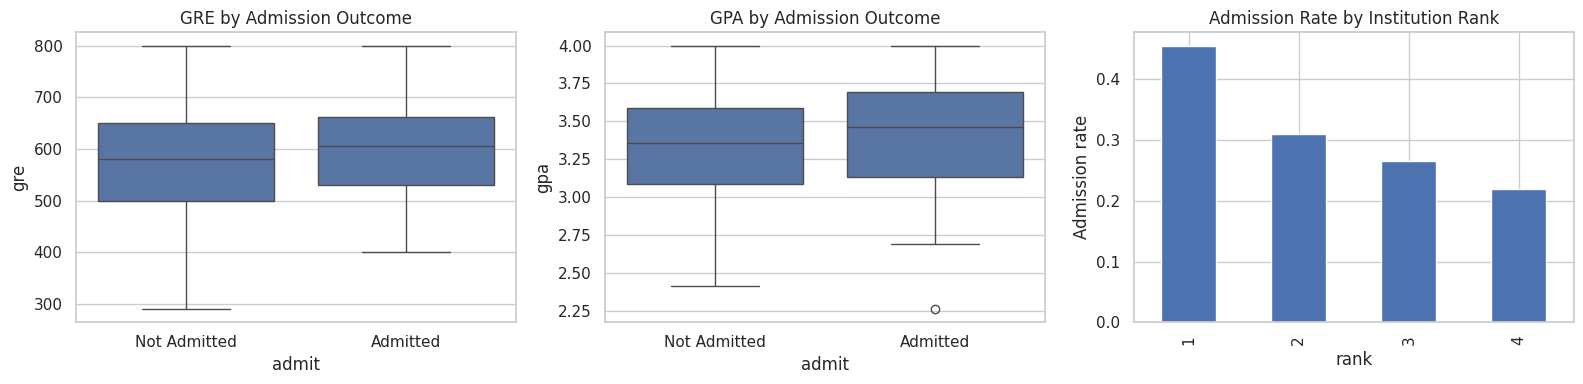

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x="admit", y="gre", ax=axes[0])
axes[0].set_title("GRE by Admission Outcome")
axes[0].set_xticklabels(["Not Admitted", "Admitted"])

sns.boxplot(data=df, x="admit", y="gpa", ax=axes[1])
axes[1].set_title("GPA by Admission Outcome")
axes[1].set_xticklabels(["Not Admitted", "Admitted"])

admit_by_rank = df.groupby("rank")["admit"].mean()
admit_by_rank.plot(kind="bar", ax=axes[2], color="#4C72B0")
axes[2].set_title("Admission Rate by Institution Rank")
axes[2].set_ylabel("Admission rate")

plt.tight_layout()
plt.show()


## 3. Fit the logistic regression with `statsmodels` (full statistical detail)

`rank` is treated as a **categorical** variable (rank 1 = reference category) since it represents
prestige tiers, not a continuous quantity.


In [6]:
logit_model = smf.logit("admit ~ gre + gpa + C(rank)", data=df).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.590155
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Wed, 29 Jul 2026   Pseudo R-squ.:                 0.03390
Time:                        09:15:54   Log-Likelihood:                -236.06
converged:                       True   LL-Null:                       -244.35
Covariance Type:            nonrobust   LLR p-value:                  0.005398
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.4533      1.246     -2.771      0.006      -5.896      -1.010
C(rank)[T.2]    -0.6481

### Odds ratios

Exponentiating the coefficients converts them into **odds ratios**, which are usually easier to interpret:
an odds ratio > 1 means the predictor increases the odds of admission; < 1 means it decreases them.


In [7]:
odds_ratios = pd.DataFrame({
    "coef": logit_model.params,
    "OR": np.exp(logit_model.params),
    "2.5% CI (OR)": np.exp(logit_model.conf_int()[0]),
    "97.5% CI (OR)": np.exp(logit_model.conf_int()[1]),
    "p-value": logit_model.pvalues
})
odds_ratios


,coef,OR,2.5% CI (OR),97.5% CI (OR),p-value
Intercept,-3.453323,0.031640,0.002750,0.364105,0.005597
C(rank)[T.2],-0.648108,0.523034,0.276014,0.991125,0.046889
C(rank)[T.3],-0.893137,0.409370,0.207481,0.807703,0.009998
C(rank)[T.4],-1.211917,0.297626,0.136278,0.650005,0.002359
gre,0.001873,1.001875,0.999795,1.003959,0.077296
gpa,0.655849,1.926777,1.055983,3.515652,0.032558


**Interpretation** (typical result on this dataset):
- Each one-point increase in `gre` is associated with higher odds of admission, holding GPA and rank constant.
- Each one-point increase in `gpa` is associated with substantially higher odds of admission.
- Compared to `rank = 1` (most prestigious institution), students from `rank = 2, 3, 4` institutions
  have progressively **lower** odds of admission, holding GRE and GPA constant.


## 4. Fit with `scikit-learn` and evaluate predictive performance

In [8]:
X = pd.get_dummies(df[["gre", "gpa", "rank"]], columns=["rank"], drop_first=True)
y = df["admit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Not Admitted", "Admitted"]))


Accuracy: 0.68
ROC-AUC : 0.596

              precision    recall  f1-score   support

Not Admitted       0.71      0.93      0.80        70
    Admitted       0.38      0.10      0.16        30

    accuracy                           0.68       100
   macro avg       0.54      0.51      0.48       100
weighted avg       0.61      0.68      0.61       100



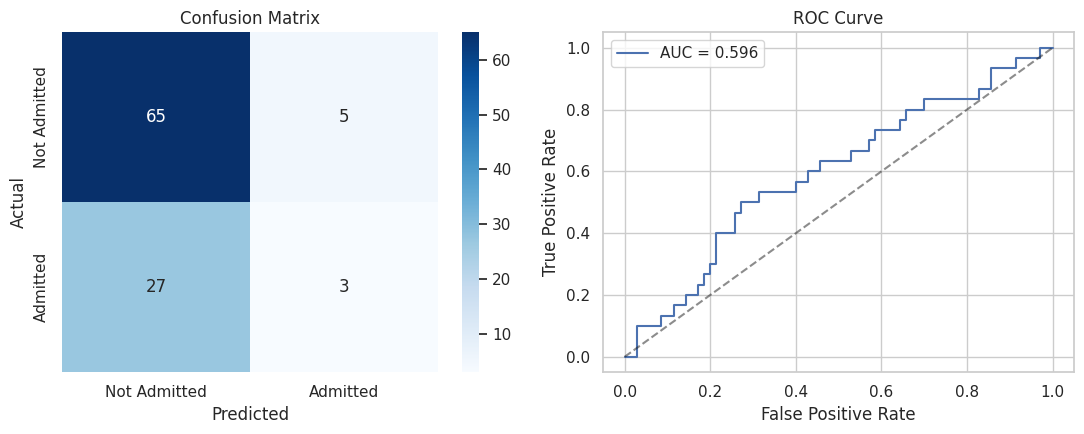

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Admitted", "Admitted"],
            yticklabels=["Not Admitted", "Admitted"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Predict admission probability for a new applicant

In [10]:
new_applicant = pd.DataFrame({"gre": [660], "gpa": [3.7], "rank": [2]})
new_applicant_enc = pd.get_dummies(new_applicant, columns=["rank"], drop_first=True)
new_applicant_enc = new_applicant_enc.reindex(columns=X.columns, fill_value=0)
new_applicant_scaled = scaler.transform(new_applicant_enc)

prob_admit = clf.predict_proba(new_applicant_scaled)[0, 1]
print(f"Predicted probability of admission: {prob_admit:.1%}")


Predicted probability of admission: 58.4%
